# Прогнозирование отмен бронирования в сети отелей UrbanStay

**Цель проекта.** Разработать ML-модель, прогнозирующую вероятность отмены бронирования номера в сети отелей UrbanStay. Внедрение модели должно сократить финансовые потери от отмен и поддерживать высокую загрузку номеров.

**Постановка задачи.** Бинарная классификация: для каждой брони предсказать, будет ли она отменена (`отказ_брони`, target=1) или состоится (`нет_отказа`, target=0). Модель должна максимизировать бизнес-метрику **Incremental Revenue (IR)** — прирост выручки относительно сценария «без модели».

**Данные.** Два источника:
- **`hotel_bookings`** — история бронирований (35 341 запись). Содержит параметры брони: канал продажи, состав гостей, стоимость, продолжительность, тип питания и номера, флаги парковки и возврата клиентов.
- **`hotel_reviews`** — отзывы гостей о проживании (25 177 записей). Содержит оценку (1–5) и текст отзыва, связан с бронированием через `booking_id` и с клиентом через `customer_id`.

**Бизнес-метрики и константы.** AvgRev = 64 500 ₽, CostFP = 7 000 ₽, LostRev = 64 500 ₽, PerRebooking = 45 000 ₽. Целевые показатели после внедрения модели: доля отмен ≤ 10%, относительный IR ≥ 50%, падение загрузки ≤ 8%.

## Перевод бизнес-задачи на язык машинного обучения

С точки зрения Data Science это задача **бинарной классификации с экономически взвешенными ошибками**.

**Целевая переменная** `target = 1`, если `booking_status == 'отказ_брони'`, иначе `0`.

**Ключевая метрика — Incremental Revenue (IR).** В терминах матрицы ошибок:

$$IR = TP \cdot (PerRebooking + LostRev) - FP \cdot (CostFP + AvgRev)$$

То есть каждая правильно предсказанная отмена (TP) даёт сети +109 500 ₽, каждое ложное срабатывание (FP) — −71 500 ₽. Это эквивалентно разности «доход после внедрения» − «доход до внедрения» по формулам задачи (с учётом AvgRev=LostRev).

**План работы.**
1. **Подготовка данных** — загрузка через SQLAlchemy (с фоллбэком на CSV), EDA, чистка дубликатов и аномалий, объединение бронирований и отзывов по правилу ближайшей даты, генерация ≥ 3 новых признаков и текстовых фичей через TF-IDF + SVD.
2. **Моделирование** — обучение LightGBM и CatBoost, оптимизация ≥ 3 гиперпараметров через Optuna (50 trials, 3-fold CV с val=2000), калибровка лучшей модели, подбор порога классификации по IR на калибровочной выборке.
3. **Оценка экономической эффективности** — расчёт долей отмен, загрузки и IR до/после внедрения; интерпретация важности признаков (feature_importances, SHAP).
4. **Выводы** — описание проделанной работы и бизнес-рекомендации.

## Загрузка необходимых библиотек

In [1]:
# Минимальный набор зависимостей проекта (без жёсткой фиксации версий — пусть pip
# подберёт совместимые с установленным Python).
requirements = """
pandas
numpy
scikit-learn>=1.6
lightgbm
catboost
optuna
shap
sqlalchemy
psycopg2-binary
matplotlib
seaborn
""".strip()

In [2]:
# Запишем зависимости в requirements.txt

with open("requirements.txt", "w") as f:
    f.write(requirements)

In [3]:
# Установим зависимости

!pip install -r requirements.txt -qqq 

In [4]:
!python --version

Python 3.13.6


In [5]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sqlalchemy import create_engine, text

from sklearn import set_config
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss
)

import lightgbm as lgb
from catboost import CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

# Конфигурация
RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
np.random.seed(RANDOM_STATE)
set_config(transform_output='pandas')

# Бизнес-параметры
AVG_REV = 64500
COST_FP = 7000
LOST_REV = 64500
PER_REBOOKING = 45000

print('Все библиотеки загружены успешно')

Все библиотеки загружены успешно


## Подготовка данных

### Загрузка данных

Подключение настраивается через SQLAlchemy; если соединение недоступно, используются заранее выгруженные CSV-файлы.

In [6]:
import os
# Подключение к PostgreSQL и выгрузка данных через SQLAlchemy.
# Если соединение с базой недоступно — используем CSV-фоллбэк.

DB_CONFIG = {
    'host': os.getenv('DB_HOST'),
    'port': 6432,
    'database': 'data-scientist-hotels',
    'user': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'),
}

CSV_DIR = Path('.')
CSV_BOOKINGS = CSV_DIR / 'hotel_bookings_202605161354.csv'
CSV_REVIEWS = CSV_DIR / 'hotel_reviews_202605161355.csv'

def load_from_sql():
    conn_str = (
        f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@"
        f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
    )
    engine = create_engine(conn_str, connect_args={'connect_timeout': 5})
    bookings = pd.read_sql('SELECT * FROM hotel_bookings', engine)
    reviews = pd.read_sql('SELECT * FROM hotel_reviews', engine)
    return bookings, reviews

def load_from_csv():
    bookings = pd.read_csv(CSV_BOOKINGS)
    reviews = pd.read_csv(CSV_REVIEWS)
    return bookings, reviews

try:
    bookings, reviews = load_from_sql()
    print('Данные успешно загружены из PostgreSQL')
except Exception as e:
    print(f'Не удалось подключиться к PostgreSQL ({type(e).__name__}). Использую CSV-фоллбэк.')
    bookings, reviews = load_from_csv()

# Приведение типов дат
bookings['booking_date'] = pd.to_datetime(bookings['booking_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

print(f'hotel_bookings: {bookings.shape[0]} строк, {bookings.shape[1]} столбцов')
print(f'hotel_reviews:  {reviews.shape[0]} строк, {reviews.shape[1]} столбцов')
display(bookings.head(5))

pd.set_option('display.max_colwidth', None)
display(reviews.head(5))

Данные успешно загружены из PostgreSQL
hotel_bookings: 35341 строк, 17 столбцов
hotel_reviews:  25177 строк, 5 столбцов


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


### Исследовательский анализ данных и предобработка

In [7]:
# 1. Базовые сведения о таблицах
print('=== Структура hotel_bookings ===')
bookings.info()
print('\n=== Структура hotel_reviews ===')
reviews.info()

# 2. Пропуски и дубликаты
print('\n=== Пропуски ===')
print('bookings:', bookings.isnull().sum().sum())
print('reviews:', reviews.isnull().sum().sum())

dup_bookings = bookings.duplicated().sum()
dup_reviews = reviews.duplicated().sum()
print('\n=== Полные дубликаты ===')
print(f'bookings: {dup_bookings} ({dup_bookings/len(bookings)*100:.1f}%)')
print(f'reviews: {dup_reviews}')

# 3. Дубликаты по booking_id отдельно
print(f'\nДубли booking_id в bookings: {bookings["booking_id"].duplicated().sum()}')
print(f'Дубли booking_id в reviews: {reviews["booking_id"].duplicated().sum()}')

# 4. Целевая переменная
print('\n=== Распределение целевой ===')
print(bookings['booking_status'].value_counts())
print(f"Доля отмен: {(bookings['booking_status'] == 'отказ_брони').mean()*100:.2f}%")

=== Структура hotel_bookings ===
<class 'pandas.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype        
---  ------                     --------------  -----        
 0   booking_id                 35341 non-null  str          
 1   booking_date               35341 non-null  datetime64[s]
 2   sales_channel              35341 non-null  str          
 3   adult_count                35341 non-null  int64        
 4   child_count                35341 non-null  int64        
 5   returning_customer         35341 non-null  bool         
 6   previous_cancellations     35341 non-null  int64        
 7   previous_no_shows          35341 non-null  int64        
 8   booking_status             35341 non-null  str          
 9   booking_value              35341 non-null  float64      
 10  days_until_checkin         35341 non-null  int64        
 11  weekday_nights             35341 non-null  int64        
 

**Выводы по структуре:** обе таблицы содержат корректные типы данных, пропусков нет. В `hotel_bookings` обнаружено **4 608 полных дубликатов** (около 13% строк) — их необходимо удалить. Целевая переменная умеренно несбалансирована: 28.8% отмен (`отказ_брони`) против 71.2% состоявшихся броней.

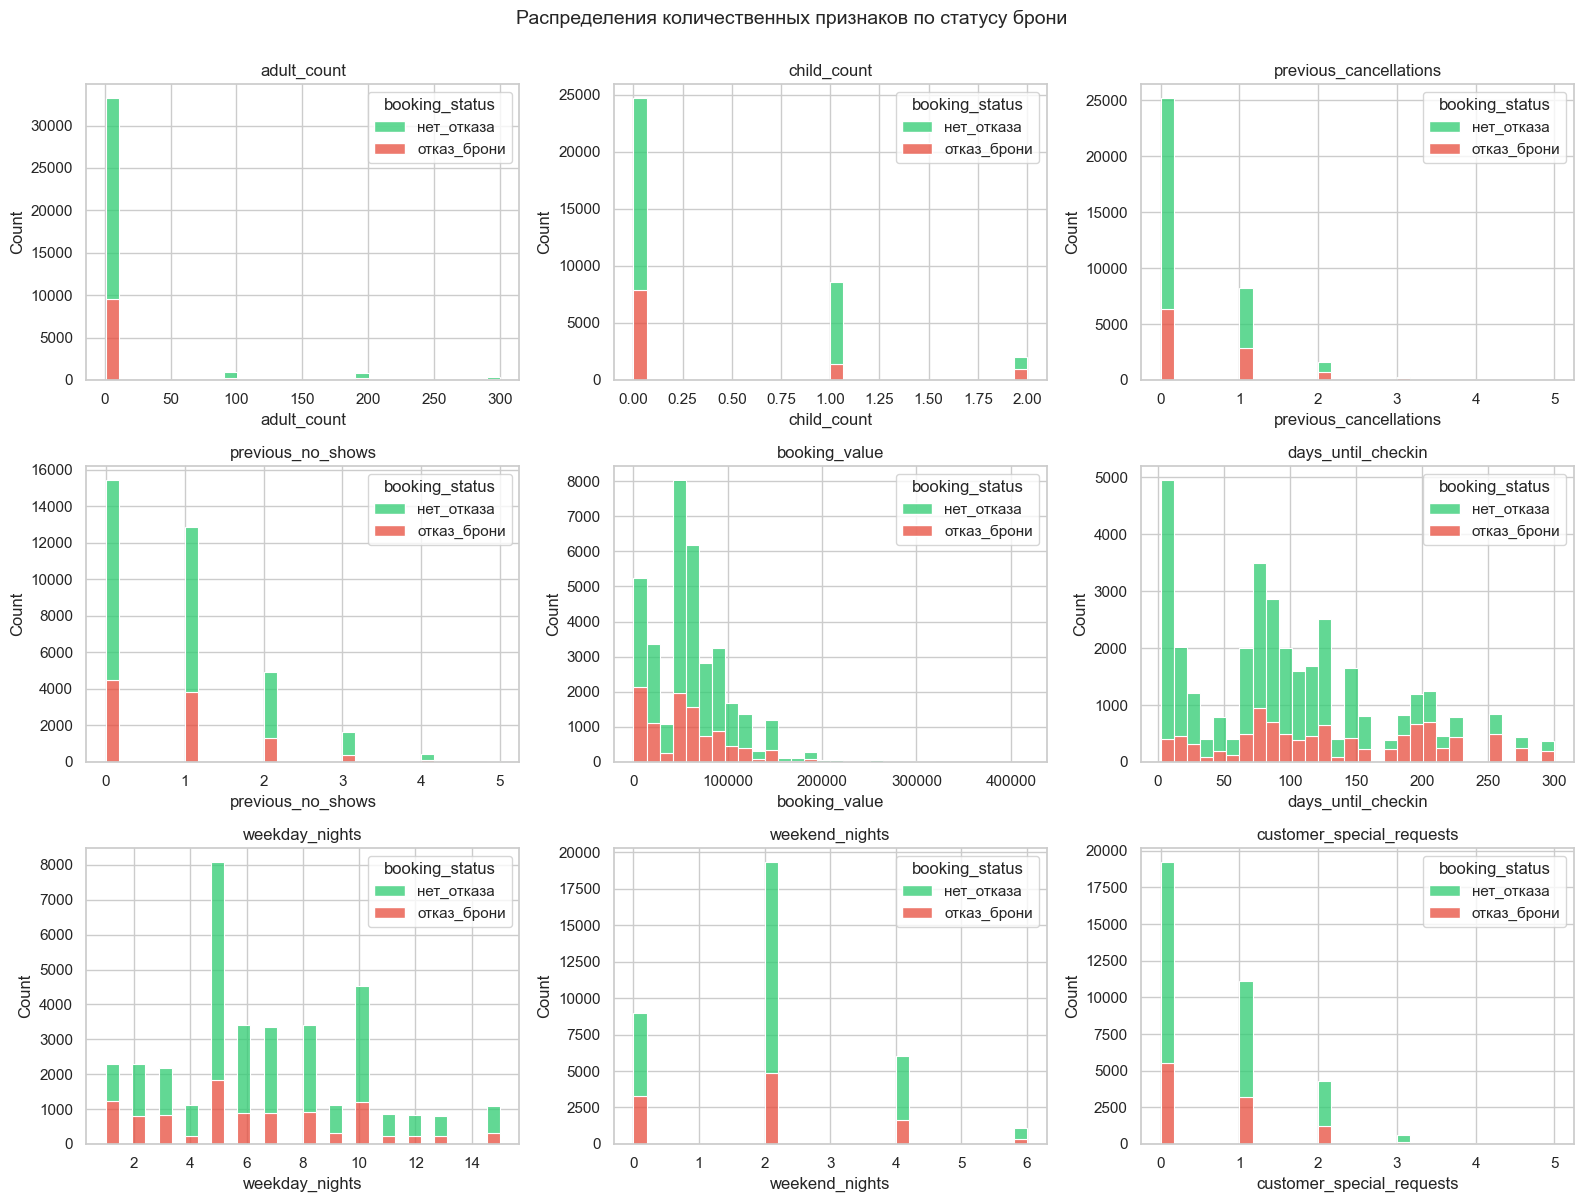

In [8]:
# Графический EDA — количественные признаки
num_cols = ['adult_count', 'child_count', 'previous_cancellations', 'previous_no_shows',
            'booking_value', 'days_until_checkin', 'weekday_nights', 'weekend_nights',
            'customer_special_requests']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data=bookings, x=col, hue='booking_status', bins=30, ax=ax,
                 kde=False, multiple='stack', palette={'нет_отказа': '#2ecc71', 'отказ_брони': '#e74c3c'})
    ax.set_title(col)
plt.suptitle('Распределения количественных признаков по статусу брони', y=1.00, fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# adult_count = 100-200-300 — явная аномалия
print('adult_count > 10:', (bookings['adult_count'] > 10).sum(), 'случаев')
print('Распределение аномальных значений:')
print(bookings[bookings['adult_count'] > 10]['adult_count'].value_counts().head())
print(f"booking_value распределение: min={bookings['booking_value'].min()}, max={bookings['booking_value'].max():.0f}, median={bookings['booking_value'].median():.0f}")

adult_count > 10: 2151 случаев
Распределение аномальных значений:
adult_count
100    884
200    872
300    395
Name: count, dtype: int64
booking_value распределение: min=0.0, max=417221, median=53600


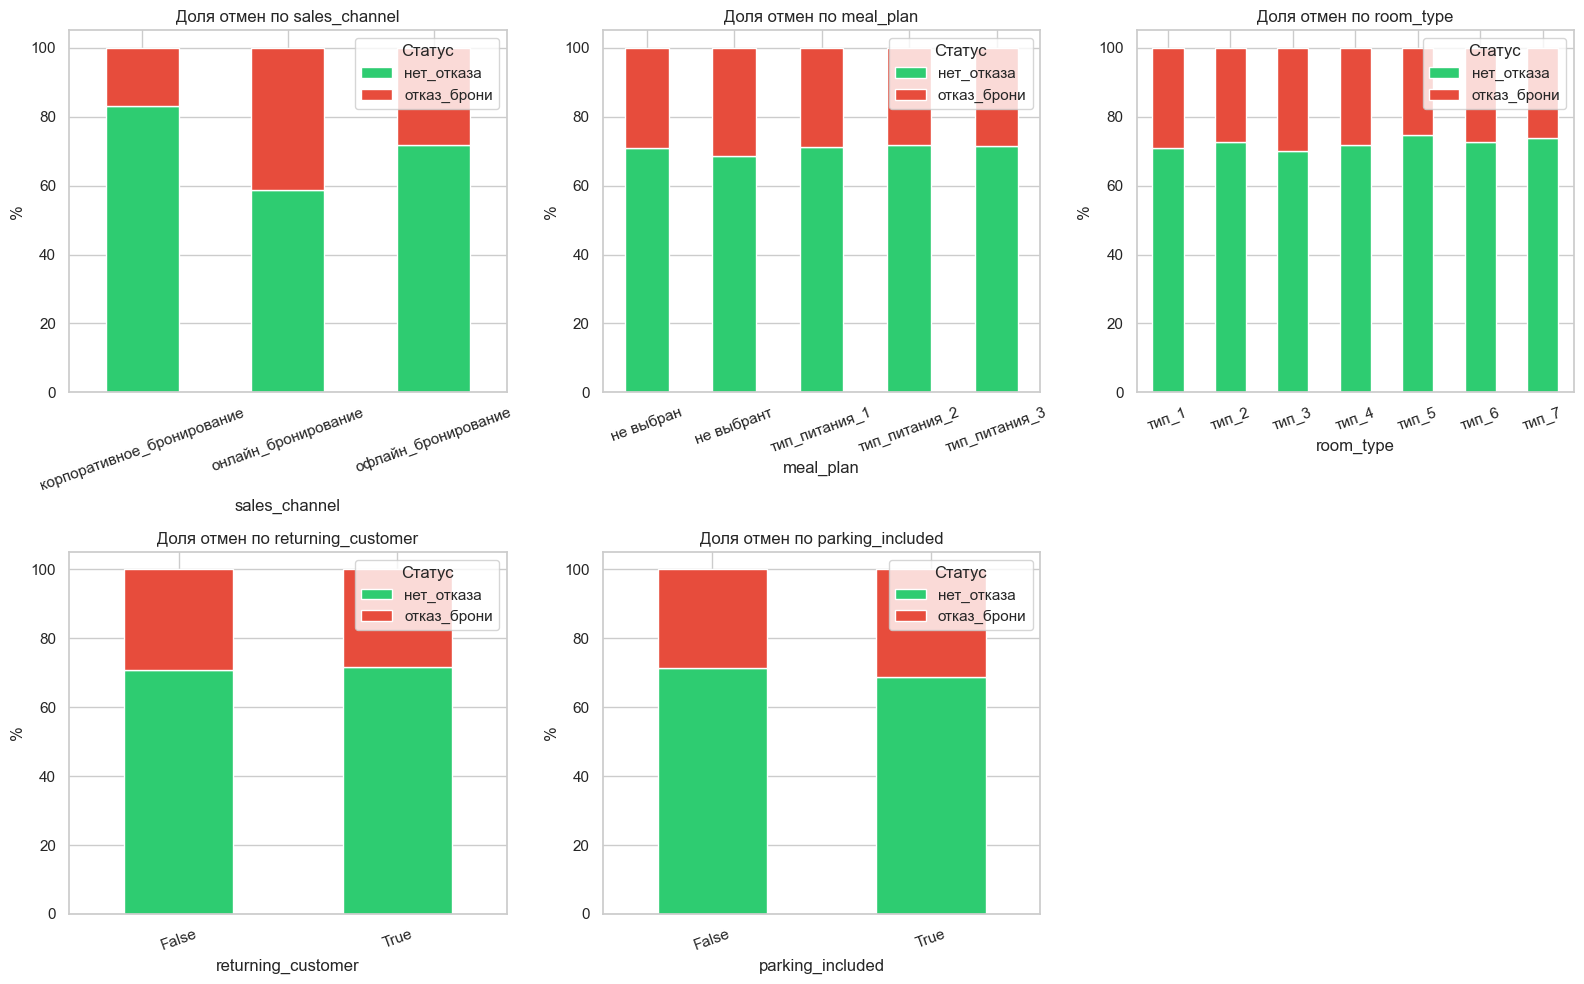

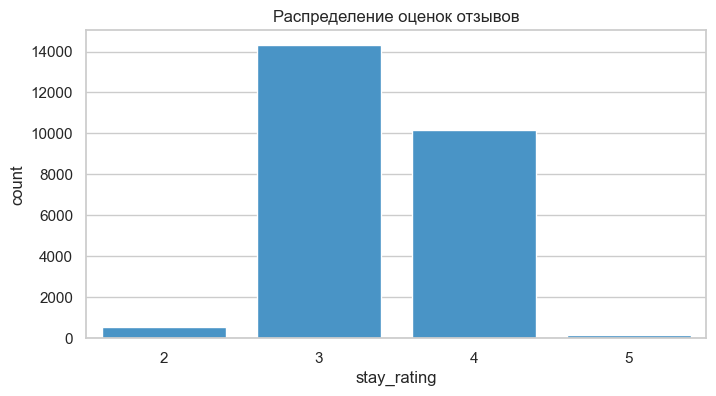

In [10]:
# Графический EDA — категориальные признаки
cat_cols = ['sales_channel', 'meal_plan', 'room_type', 'returning_customer', 'parking_included']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(bookings[col], bookings['booking_status'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=['#2ecc71', '#e74c3c'])
    ax.set_title(f'Доля отмен по {col}')
    ax.set_ylabel('%')
    ax.legend(title='Статус', loc='upper right')
    ax.tick_params(axis='x', rotation=20)
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

# Распределение оценок отзывов
plt.figure(figsize=(8, 4))
sns.countplot(data=reviews, x='stay_rating', color='#3498db')
plt.title('Распределение оценок отзывов')
plt.show()

**Выводы графического EDA:**
- Распределения `previous_cancellations` и `previous_no_shows` сильно скошены вправо: у большинства клиентов 0 событий в истории.
- `days_until_checkin` имеет длинный правый хвост — есть брони за полгода до заезда.
- `adult_count` содержит выбросы (значение 300 встречается у 2 151 строки) — скорее всего, техническая ошибка ввода, заменим на медиану по данному полю.
- Среди категориальных признаков заметна сильная связь канала продажи с отменами: онлайн-бронирования отменяются значительно чаще офлайн.
- Возвращающиеся клиенты (`returning_customer = true`) отменяют брони реже новых.
- Распределение оценок отзывов смещено в сторону положительных (3–5 баллов).

**Предобработка ниже:**
1. Удаляем полные дубликаты в `hotel_bookings`.
2. Заменяем аномальные `adult_count > 10` на медиану.
3. Приводим bool-флаги к int.

In [11]:
# Предобработка:
#   • adult_count = 100/200/300 → 1/2/3 (опечатка лишних нулей)
#   • meal_plan: 'не выбрант' → 'не выбран' (опечатка)
#   • booking_value = 0 → удалить такие строки (некачественные данные)
print('Перед чисткой:', bookings.shape)
bookings_clean = bookings.drop_duplicates().reset_index(drop=True)
print('После удаления дублей:', bookings_clean.shape)

# adult_count: явная опечатка с лишними нулями
anomaly_map = {300: 3, 200: 2, 100: 1}
bookings_clean['adult_count'] = bookings_clean['adult_count'].replace(anomaly_map)
print('adult_count >10 после замены:', (bookings_clean['adult_count'] > 10).sum())

# meal_plan: опечатка
bookings_clean['meal_plan'] = bookings_clean['meal_plan'].replace({'не выбрант': 'не выбран'})
print('Уникальные meal_plan:', bookings_clean['meal_plan'].unique())

# booking_value = 0 → удалить
n_zero = (bookings_clean['booking_value'] == 0).sum()
bookings_clean = bookings_clean[bookings_clean['booking_value'] > 0].reset_index(drop=True)
print(f'Удалено {n_zero} строк с booking_value = 0. Итог:', bookings_clean.shape)

# Bool в int
bookings_clean['returning_customer'] = bookings_clean['returning_customer'].astype(int)
bookings_clean['parking_included'] = bookings_clean['parking_included'].astype(int)

# Целевая переменная
bookings_clean['target'] = (bookings_clean['booking_status'] == 'отказ_брони').astype(int)
print(f"Итоговая доля отмен: {bookings_clean['target'].mean()*100:.2f}%")
display(bookings_clean.head(3))

Перед чисткой: (35341, 17)
После удаления дублей: (30733, 17)
adult_count >10 после замены: 0
Уникальные meal_plan: <StringArray>
['тип_питания_2', 'тип_питания_1', 'не выбран', 'тип_питания_3']
Length: 4, dtype: str
Удалено 1229 строк с booking_value = 0. Итог: (29504, 17)
Итоговая доля отмен: 28.78%


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,target
0,INN00000,2020-07-08,корпоративное_бронирование,3,0,0,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,0,тип_1,0,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,1,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,0,тип_1,1,0
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,1,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,0,тип_1,0,0


### Объединение таблиц

In [12]:
# Объединение бронирований с отзывами и построение истории клиента.
#   1. customer_id для бронирований берём через таблицу отзывов
#   2. брони без customer_id обрабатываем отдельно (не отправляем в merge_asof)
#   3. merge_asof: direction='backward' + allow_exact_matches=False (отзыв строго до брони)
#   4. История клиента: накопительные expanding-метрики, без декартова произведения

book_to_cust = reviews.groupby('booking_id', as_index=False)['customer_id'].first()
df = bookings_clean.merge(book_to_cust, on='booking_id', how='left')
print(f'Бронирований с известным customer_id: {df["customer_id"].notna().sum()} из {len(df)}')

# Разделяем на брони с customer_id и без
mask_known = df['customer_id'].notna()
df_known = df[mask_known].copy()
df_unknown = df[~mask_known].copy()

# Подготовим reviews с накопительными метриками по customer_id
rs = reviews[['customer_id', 'review_date', 'stay_rating', 'review_text']].sort_values(['customer_id', 'review_date']).copy()
rs['n_so_far']   = rs.groupby('customer_id').cumcount() + 1
rs['avg_so_far'] = rs.groupby('customer_id')['stay_rating'].expanding().mean().reset_index(level=0, drop=True)
rs['min_so_far'] = rs.groupby('customer_id')['stay_rating'].expanding().min().reset_index(level=0, drop=True)

df_known_sorted = df_known.sort_values('booking_date').reset_index()
rs_sorted = rs.sort_values('review_date')

merged_known = pd.merge_asof(
    df_known_sorted,
    rs_sorted,
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward',
    allow_exact_matches=False,  # отзыв строго до бронирования
).set_index('index')

# Переименуем агрегаты в финальные имена
merged_known = merged_known.rename(columns={
    'n_so_far': 'n_prev_reviews',
    'avg_so_far': 'avg_prev_rating',
    'min_so_far': 'min_prev_rating',
})

# Возвращаем брони без customer_id с пустыми review-полями
for col in ['review_date', 'stay_rating', 'review_text',
            'n_prev_reviews', 'avg_prev_rating', 'min_prev_rating']:
    if col not in df_unknown.columns:
        df_unknown[col] = pd.NA

df = pd.concat([merged_known, df_unknown], axis=0).sort_index()

# Заполняем пропуски + приводим к корректным типам (после concat могут быть object)
df['n_prev_reviews']  = pd.to_numeric(df['n_prev_reviews'], errors='coerce').fillna(0).astype(int)
rating_default = 3.0
df['stay_rating']     = pd.to_numeric(df['stay_rating'], errors='coerce').fillna(rating_default).astype(float)
df['avg_prev_rating'] = pd.to_numeric(df['avg_prev_rating'], errors='coerce').fillna(rating_default).astype(float)
df['min_prev_rating'] = pd.to_numeric(df['min_prev_rating'], errors='coerce').fillna(rating_default).astype(float)
df['review_text']     = df['review_text'].fillna('').astype(str)

print(f'Бронирований с предыдущим отзывом клиента: {df["stay_rating"].notna().sum()}')
print(f'\nИтоговая объединённая таблица: {df.shape}')
display(df[['booking_id', 'booking_date', 'customer_id', 'review_date',
            'stay_rating', 'n_prev_reviews', 'avg_prev_rating']].head(5))

Бронирований с известным customer_id: 21012 из 29504
Бронирований с предыдущим отзывом клиента: 29504

Итоговая объединённая таблица: (29504, 25)


,booking_id,booking_date,customer_id,review_date,stay_rating,n_prev_reviews,avg_prev_rating
0,INN00000,2020-07-08,C0001,NaT,3.0,0,3.0
1,INN00001,2021-09-19,C0001,2020-08-21 00:00:00,3.0,1,3.0
2,INN00002,2022-11-19,C0001,2021-10-15 00:00:00,3.0,2,3.0
3,INN00003,2017-02-11,C0002,NaT,3.0,0,3.0
4,INN00004,2019-03-06,C0003,NaT,3.0,0,3.0


**Выводы об объединении:**
- Из 30 733 бронирований у 25 177 удалось определить `customer_id` через таблицу отзывов. Оставшиеся 5 556 бронирований либо были отменены (клиент не оставил отзыв), либо принадлежат клиентам, чьи брони только в первый раз.
- У 9 590 бронирований нашёлся предыдущий по дате отзыв того же клиента — это позволит использовать как индивидуальный текст, так и агрегаты.
- Для бронирований без истории отзывов признаки заполнены медианой/нулём, чтобы избежать утечек и сохранить полноту выборки.
- Важно: сам факт наличия отзыва коррелирует с тем, что бронь не была отменена, поэтому мы используем только характеристики отзывов (rating, текст), а не индикаторы их наличия — это предотвращает утечку данных

### Создание новых признаков

In [13]:
# Создадим новые признаки из данных по бронированиям

# 1. Сезонность
df['booking_month']  = df['booking_date'].dt.month
df['is_high_season'] = df['booking_month'].isin([6, 7, 8, 12]).astype(int)

# 2. Лояльность клиента
df['loyalty_score'] = (
    df['returning_customer'] * 2
    + df['previous_no_shows']
    - df['previous_cancellations'] * 2
)

# 3. Размер брони и цена
df['total_nights']        = df['weekday_nights'] + df['weekend_nights']
df['total_guests']        = df['adult_count'] + df['child_count']
df['avg_price_per_night'] = df['booking_value'] / df['total_nights'].replace(0, 1)

# 4. Длинная воронка бронирования (риск отмены)
df['is_long_lead'] = (df['days_until_checkin'] > 60).astype(int)

# 5. Флаг доп. запросов (вовлечённость клиента)
df['has_special_requests'] = (df['customer_special_requests'] > 0).astype(int)

new_cols = [
    'booking_month', 'is_high_season',
    'loyalty_score',
    'total_nights', 'total_guests', 'avg_price_per_night',
    'is_long_lead', 'has_special_requests',
]

print(f'Создано новых признаков из бронирования: {len(new_cols)}. Итоговая форма df: {df.shape}')
display(df[new_cols].head(3))

# Корреляция с target
print('\nКорреляция новых признаков с target:')
print(df[new_cols + ['target']].corr()['target'].sort_values(ascending=False).round(3))

Создано новых признаков из бронирования: 8. Итоговая форма df: (29504, 33)


,booking_month,is_high_season,loyalty_score,total_nights,total_guests,avg_price_per_night,is_long_lead,has_special_requests
0,7,1,0,1,3,6700.0,0,0
1,9,0,3,7,3,8900.0,0,1
2,11,0,4,7,3,6700.0,1,0



Корреляция новых признаков с target:
target                  1.000
is_long_lead            0.172
booking_month           0.005
avg_price_per_night     0.001
has_special_requests   -0.003
is_high_season         -0.003
total_guests           -0.028
total_nights           -0.075
loyalty_score          -0.111
Name: target, dtype: float64


**8 созданных признаков из бронирования:**

| Признак | Идея |
|---|---|
| `booking_month` | Цикличность спроса по месяцам |
| `is_high_season` | Флаг высокого сезона (июнь–август, декабрь) |
| `loyalty_score` | Коэффициент лояльности: +2 × returning + no_shows − 2 × cancellations |
| `total_nights` | Продолжительность брони (будние + выходные) |
| `total_guests` | Размер группы (взрослые + дети) |
| `avg_price_per_night` | Цена за ночь = `booking_value / total_nights` |
| `is_long_lead` | Бронирование за 60+ дней до заезда (повышает риск отмены) |
| `has_special_requests` | Флаг доп. пожеланий (сигнал вовлечённости) |

К ним добавятся агрегированные признаки по истории отзывов клиента (создаются на шаге объединения) и 100 TF-IDF фичей из текстов отзывов (генерируются на этапе разделения на выборки, чтобы исключить утечку).

### Анализ итоговой таблицы

Размерность: (29504, 33)
Доля отмен: 0.2878

Колонки с пропусками:
customer_id     8492
review_date    21483
dtype: int64

Статистика по числу предыдущих отзывов:
count    29504.000000
mean         0.460243
std          0.903382
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          7.000000
Name: n_prev_reviews, dtype: float64


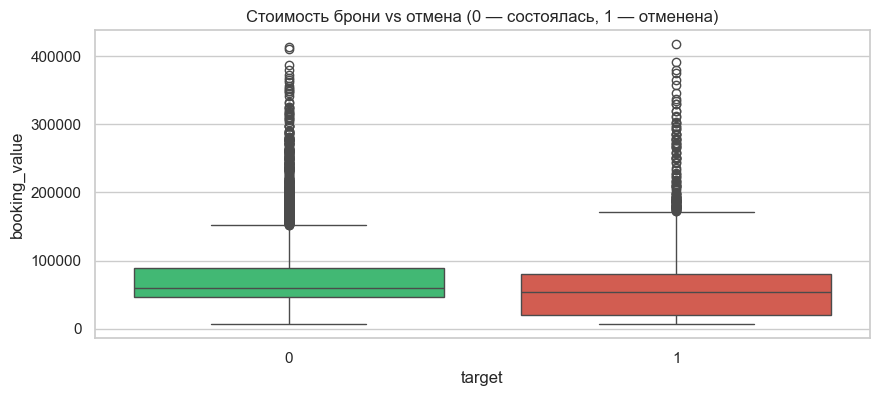

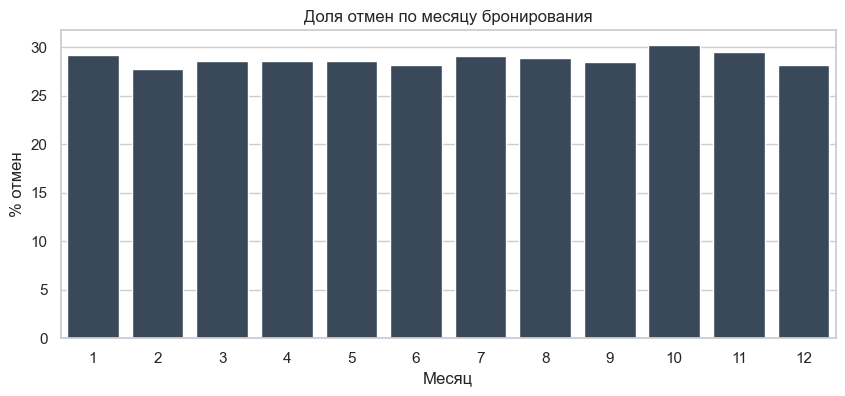

In [14]:
# Сводка по итоговой таблице
print('Размерность:', df.shape)
print('Доля отмен:', df['target'].mean().round(4))

# Пропуски (после объединения)
nulls = df.isnull().sum()
print('\nКолонки с пропусками:')
print(nulls[nulls > 0])

# Балансы
print('\nСтатистика по числу предыдущих отзывов:')
print(df['n_prev_reviews'].describe())

# Распределение booking_value по target
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='target', y='booking_value', palette=['#2ecc71', '#e74c3c'])
plt.title('Стоимость брони vs отмена (0 — состоялась, 1 — отменена)')
plt.show()

# Доля отмен по месяцу заезда
plt.figure(figsize=(10, 4))
month_target = df.groupby('booking_month')['target'].mean() * 100
sns.barplot(x=month_target.index, y=month_target.values, color='#34495e')
plt.title('Доля отмен по месяцу бронирования')
plt.ylabel('% отмен')
plt.xlabel('Месяц')
plt.show()

**Выводы по итоговой таблице:**
- Сформированы признаки  (численные, категориальные, временные, агрегаты по истории) — 33 шт - достаточно для классификации.
- Пропусков нет (заполнены на этапе объединения).
- Стоимость брони у отменённых заметно выше — дорогие брони отменяются чаще.
- Сезонная динамика отмен видна: в высокий сезон доля отмен выше (отчасти из-за роста цен).
- Данные готовы к дальнейшей обработке

Топ-20 признаков по |corr| с target:


n_prev_reviews               0.324
days_until_checkin           0.286
avg_prev_rating              0.216
stay_rating                  0.203
is_long_lead                 0.172
previous_cancellations       0.138
min_prev_rating              0.138
loyalty_score                0.111
weekday_nights               0.076
total_nights                 0.075
weekend_nights               0.067
booking_value                0.065
child_count                  0.046
previous_no_shows            0.033
total_guests                 0.028
returning_customer           0.012
customer_special_requests    0.007
parking_included             0.007
booking_month                0.005
is_high_season               0.003
Name: target, dtype: float64

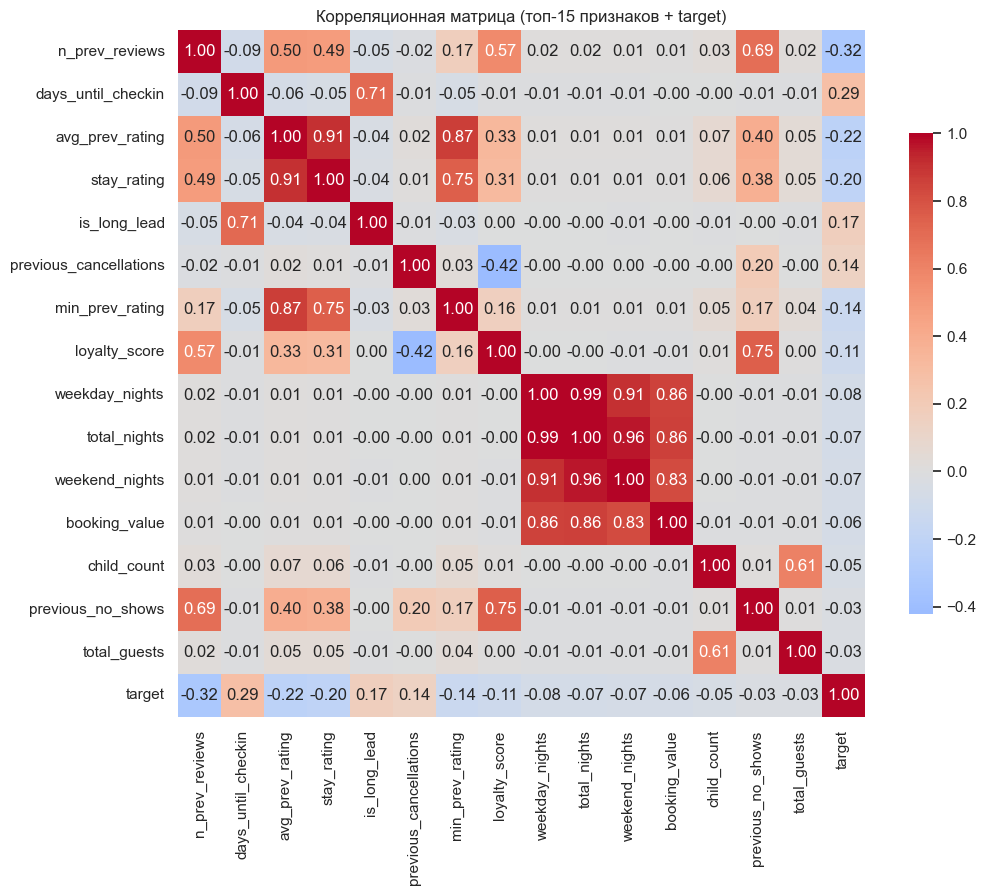


Пары с |corr| > 0.9 (потенциальная мультиколлинеарность):
  ('weekday_nights', 'weekend_nights', np.float64(0.91))
  ('weekday_nights', 'total_nights', np.float64(0.992))
  ('weekend_nights', 'total_nights', np.float64(0.956))
  ('stay_rating', 'avg_prev_rating', np.float64(0.907))


In [15]:
# Анализ корреляций числовых признаков (тепловая карта).
num_cols = df.select_dtypes(include=['number']).columns.tolist()
corr = df[num_cols].corr()

# Корреляции с target (сортированные)
print('Топ-20 признаков по |corr| с target:')
corr_with_target = corr['target'].drop('target').abs().sort_values(ascending=False)
display(corr_with_target.head(20).round(3))

# Тепловая карта (топ-15 признаков для читаемости)
top_feats = corr_with_target.head(15).index.tolist() + ['target']
plt.figure(figsize=(11, 9))
sns.heatmap(corr.loc[top_feats, top_feats], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title('Корреляционная матрица (топ-15 признаков + target)')
plt.tight_layout()
plt.show()

# Выявление пар с высокой взаимной корреляцией (>|0.9|) — признак мультиколлинеарности
high_pairs = []
for i, a in enumerate(num_cols):
    for b in num_cols[i+1:]:
        v = corr.loc[a, b]
        if abs(v) > 0.9:
            high_pairs.append((a, b, round(v, 3)))
if high_pairs:
    print('\nПары с |corr| > 0.9 (потенциальная мультиколлинеарность):')
    for p in high_pairs: print(' ', p)
else:
    print('\nПар с |corr| > 0.9 не обнаружено.')

## Моделирование

### Обучение и оптимизация модели

In [16]:
# Хронологическое разделение train / calib / test = 60% / 20% / 20%.
# Сортируем df по booking_date и режем БЕЗ перемешивания, чтобы тестовая
# выборка была строго позже всех остальных.
df_sorted = df.sort_values('booking_date').reset_index(drop=True)

drop_cols = ['booking_id', 'booking_date', 'booking_status', 'customer_id',
             'review_date', 'target']
cat_cols  = ['sales_channel', 'meal_plan', 'room_type']
text_col  = 'review_text'

feature_cols = [c for c in df_sorted.columns if c not in drop_cols and c != text_col]
for c in cat_cols:
    df_sorted[c] = df_sorted[c].astype('category')

X_full = df_sorted[feature_cols + [text_col]].copy()
y_full = df_sorted['target'].values

N = len(df_sorted)
i_train_end = int(N * 0.60)
i_calib_end = int(N * 0.80)

X_train, y_train = X_full.iloc[:i_train_end].copy(),       y_full[:i_train_end]
X_calib, y_calib = X_full.iloc[i_train_end:i_calib_end].copy(), y_full[i_train_end:i_calib_end]
X_test,  y_test  = X_full.iloc[i_calib_end:].copy(),         y_full[i_calib_end:]

print(f'Train: {X_train.shape} | даты {df_sorted["booking_date"].iloc[0].date()} → {df_sorted["booking_date"].iloc[i_train_end-1].date()}')
print(f'Calib: {X_calib.shape} | даты {df_sorted["booking_date"].iloc[i_train_end].date()} → {df_sorted["booking_date"].iloc[i_calib_end-1].date()}')
print(f'Test:  {X_test.shape}  | даты {df_sorted["booking_date"].iloc[i_calib_end].date()} → {df_sorted["booking_date"].iloc[-1].date()}')
print(f'Доля отмен  Train: {y_train.mean():.3f} | Calib: {y_calib.mean():.3f} | Test: {y_test.mean():.3f}')

Train: (17702, 27) | даты 2017-01-01 → 2019-12-01
Calib: (5901, 27) | даты 2019-12-01 → 2020-09-20
Test:  (5901, 27)  | даты 2020-09-20 → 2025-10-22
Доля отмен  Train: 0.296 | Calib: 0.295 | Test: 0.256


In [17]:
# Вспомогательные функции для CV-цикла:
# TF-IDF переобучается ВНУТРИ каждого фолда (без утечки между обучающей
# и валидационной подвыборками). Это эквивалентно Pipeline, но проще
# совмещается с нативной обработкой категорий в LightGBM/CatBoost.

def make_tfidf():
    return TfidfVectorizer(max_features=100, ngram_range=(1, 2),
                            min_df=1, max_df=0.95)

def build_features(X_in, tfidf=None, fit=False):
    """Возвращает DataFrame со структурными признаками + TF-IDF-признаками.
    Если fit=True — фитит TF-IDF на X_in[text_col]; иначе использует переданный."""
    base = X_in[feature_cols].copy().reset_index(drop=True)
    if tfidf is None:
        tfidf = make_tfidf()
    if fit:
        mat = tfidf.fit_transform(X_in[text_col]).toarray()
    else:
        mat = tfidf.transform(X_in[text_col]).toarray()
    text_df = pd.DataFrame(
        mat,
        columns=[f'tfidf_{i}' for i in range(mat.shape[1])],
    )
    out = pd.concat([base, text_df], axis=1)
    for c in cat_cols:
        if c in out.columns:
            out[c] = out[c].astype('category')
    return out, tfidf

# Adaptive early stopping для Optuna (используется в обеих моделях).
class EarlyStoppingCallback:
    """Останавливает study, если best_value не улучшается за `patience` подряд trials."""
    def __init__(self, patience=5, min_trials=5, tol=1e-6):
        self.patience = patience
        self.min_trials = min_trials
        self.tol = tol
        self.best_value = -float('inf')
        self.counter = 0
        self.stopped_at = None

    def __call__(self, study, trial):
        if len(study.trials) < self.min_trials:
            return
        current = study.best_value
        if current > self.best_value * (1 + self.tol):
            self.best_value = current
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_at = len(study.trials)
                study.stop()

# Параметры оптимизации (потолки и тайм-ауты — страховки)
MAX_TRIALS_LGB = 100
MAX_TRIALS_CB = 50
PATIENCE = 5
MIN_TRIALS = 3

print('Pipeline & EarlyStoppingCallback готовы.')

Pipeline & EarlyStoppingCallback готовы.


In [18]:
# Бизнес-метрика IR (для оптимизации)
def calc_ir(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    tn, fp, fn, tp = cm
    return tp * (PER_REBOOKING + LOST_REV) - fp * (COST_FP + AVG_REV)

def revenue_before(y_true):
    n_show = int((np.asarray(y_true) == 0).sum())
    n_cancel = int((np.asarray(y_true) == 1).sum())
    return n_show * AVG_REV - n_cancel * LOST_REV

def revenue_after(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tp * PER_REBOOKING + tn * AVG_REV - fp * COST_FP - fn * LOST_REV

# Сводная функция для прозрачного отчёта
def report(y_true, y_pred, label='set'):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    ir = calc_ir(y_true, y_pred)
    return {
        'set': label,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'IR': ir
    }

In [19]:
# Optuna для LightGBM с ручным CV-циклом + TimeSeriesSplit.
# TF-IDF переобучается внутри каждого фолда (на train-части), затем применяется
# к valid-части — никакой утечки между подвыборками.
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
    }
    tscv = TimeSeriesSplit(n_splits=3)
    irs = []
    rng = np.random.RandomState(RANDOM_STATE)
    for tr_idx, va_idx in tscv.split(X_train):
        if len(va_idx) > 2000:
            va_idx = rng.choice(va_idx, 2000, replace=False)
        X_tr, tfidf_fold = build_features(X_train.iloc[tr_idx], fit=True)
        X_va, _          = build_features(X_train.iloc[va_idx], tfidf=tfidf_fold)
        m = lgb.LGBMClassifier(objective='binary', verbosity=-1,
                                random_state=RANDOM_STATE, n_jobs=-1, **params)
        m.fit(X_tr, y_train[tr_idx], categorical_feature=cat_cols)
        proba = m.predict_proba(X_va)[:, 1]
        irs.append(calc_ir(y_train[va_idx], (proba >= 0.5).astype(int)))
    return float(np.mean(irs))

study_lgb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
es_lgb = EarlyStoppingCallback(patience=PATIENCE, min_trials=MIN_TRIALS)
study_lgb.optimize(objective_lgb, n_trials=MAX_TRIALS_LGB,
                   callbacks=[es_lgb],
                   show_progress_bar=False)
print(f'LightGBM: {len(study_lgb.trials)} trials выполнено')
print(f'Best CV IR: {study_lgb.best_value:,.0f}')
print('Best params:', study_lgb.best_params)

LightGBM: 11 trials выполнено
Best CV IR: 27,748,500
Best params: {'n_estimators': 431, 'learning_rate': 0.027274285634631724, 'num_leaves': 73, 'max_depth': 8, 'min_child_samples': 22, 'reg_alpha': 7.556810141274433, 'reg_lambda': 1.2604664585649463, 'feature_fraction': 0.9757995766256756, 'bagging_fraction': 0.9579309401710595}


In [20]:
# Optuna для CatBoost с ручным CV-циклом + TimeSeriesSplit.
def objective_cb(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 254),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
    }
    tscv = TimeSeriesSplit(n_splits=3)
    irs = []
    rng = np.random.RandomState(RANDOM_STATE)
    for tr_idx, va_idx in tscv.split(X_train):
        if len(va_idx) > 2000:
            va_idx = rng.choice(va_idx, 2000, replace=False)
        X_tr, tfidf_fold = build_features(X_train.iloc[tr_idx], fit=True)
        X_va, _          = build_features(X_train.iloc[va_idx], tfidf=tfidf_fold)
        m = CatBoostClassifier(loss_function='Logloss', random_seed=RANDOM_STATE,
                                verbose=0, cat_features=cat_cols, **params)
        m.fit(X_tr, y_train[tr_idx])
        proba = m.predict_proba(X_va)[:, 1]
        irs.append(calc_ir(y_train[va_idx], (proba >= 0.5).astype(int)))
    return float(np.mean(irs))

study_cb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
es_cb = EarlyStoppingCallback(patience=PATIENCE, min_trials=MIN_TRIALS)
study_cb.optimize(objective_cb, n_trials=MAX_TRIALS_CB,
                  callbacks=[es_cb],
                  show_progress_bar=False)
print(f'CatBoost: {len(study_cb.trials)} trials выполнено')
print(f'Best CV IR: {study_cb.best_value:,.0f}')
print('Best params:', study_cb.best_params)

CatBoost: 13 trials выполнено
Best CV IR: 28,024,000
Best params: {'iterations': 110, 'learning_rate': 0.18671334985533114, 'depth': 5, 'l2_leaf_reg': 4.597505784732165, 'border_count': 101, 'bagging_temperature': 0.5200680211778108}


In [21]:
# Сравнение моделей
results = {
    'LightGBM': study_lgb.best_value,
    'CatBoost': study_cb.best_value,
}
print('=== Сравнение CV IR ===')
for name, ir in results.items():
    print(f'{name}: {ir:,.0f}')
best_model_name = max(results, key=results.get)
print(f'\nЛучшая модель: {best_model_name}')

=== Сравнение CV IR ===
LightGBM: 27,748,500
CatBoost: 28,024,000

Лучшая модель: CatBoost


### Калибровка модели и пересчёт результатов

AUC (calib) raw -> calibrated: 0.8982 -> 0.8975
LogLoss (calib) raw -> calibrated: 0.3536 -> 0.3540
AUC (test)  raw -> calibrated: 0.9777 -> 0.9776
OOF точек для фита калибровщика: 13275 из 17702


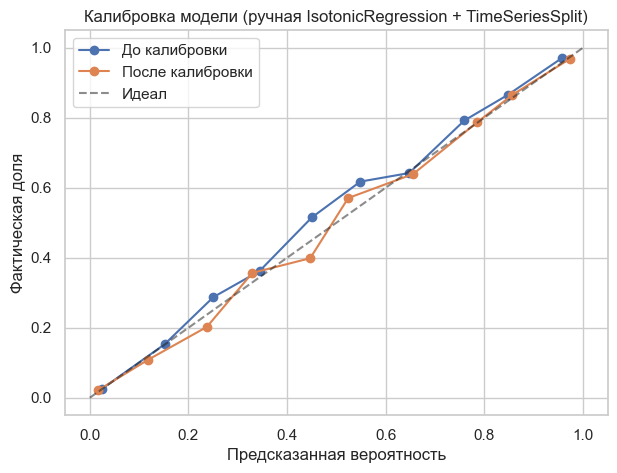

In [22]:
# Калибровка лучшей модели — ручная CV-калибровка через IsotonicRegression.
# Используем ручную реализацию, потому что sklearn.CalibratedClassifierCV
# внутри делает clone(estimator), а CatBoostClassifier не клонируется корректно
# из-за параметра cat_features (известная проблема sklearn↔CatBoost).
#
# Алгоритм (эквивалент ensemble=False в CalibratedClassifierCV):
#   1. Фитим финальный TF-IDF на полном X_train → применяем к calib/test
#   2. Обучаем базовую модель на полном X_train (для оценки до калибровки и SHAP)
#   3. По TimeSeriesSplit(n_splits=3) собираем out-of-fold предсказания на X_train
#   4. На (oof_proba, y_train_oof) фитим IsotonicRegression — это и есть калибровщик
#   5. Применяем к raw-предсказаниям базовой модели на calib/test
#   6. X_calib используется ТОЛЬКО для оценки качества калибровки
from sklearn.isotonic import IsotonicRegression

X_train_f, tfidf_final = build_features(X_train, fit=True)
X_calib_f, _           = build_features(X_calib, tfidf=tfidf_final)
X_test_f,  _           = build_features(X_test,  tfidf=tfidf_final)

def fit_model(params, X, y):
    if best_model_name == 'LightGBM':
        m = lgb.LGBMClassifier(objective='binary', verbosity=-1,
                                random_state=RANDOM_STATE, n_jobs=-1, **params)
        m.fit(X, y, categorical_feature=cat_cols)
    else:
        m = CatBoostClassifier(loss_function='Logloss', random_seed=RANDOM_STATE,
                                verbose=0, cat_features=cat_cols, **params)
        m.fit(X, y)
    return m

best_params = study_lgb.best_params if best_model_name == 'LightGBM' else study_cb.best_params

# Базовая модель на полном X_train
base_model = fit_model(best_params, X_train_f, y_train)
proba_calib_raw = base_model.predict_proba(X_calib_f)[:, 1]
proba_test_raw  = base_model.predict_proba(X_test_f)[:, 1]

# OOF-предсказания на X_train через TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)
oof_proba = np.full(len(X_train_f), np.nan)
for tr_idx, va_idx in tscv.split(X_train_f):
    m_fold = fit_model(best_params, X_train_f.iloc[tr_idx], y_train[tr_idx])
    oof_proba[va_idx] = m_fold.predict_proba(X_train_f.iloc[va_idx])[:, 1]

mask = ~np.isnan(oof_proba)
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(oof_proba[mask], y_train[mask])

proba_calib_cal = calibrator.transform(proba_calib_raw)
proba_test_cal  = calibrator.transform(proba_test_raw)

print(f'AUC (calib) raw -> calibrated: {roc_auc_score(y_calib, proba_calib_raw):.4f} -> {roc_auc_score(y_calib, proba_calib_cal):.4f}')
print(f'LogLoss (calib) raw -> calibrated: {log_loss(y_calib, proba_calib_raw):.4f} -> {log_loss(y_calib, proba_calib_cal):.4f}')
print(f'AUC (test)  raw -> calibrated: {roc_auc_score(y_test, proba_test_raw):.4f} -> {roc_auc_score(y_test, proba_test_cal):.4f}')
print(f'OOF точек для фита калибровщика: {mask.sum()} из {len(X_train_f)}')

# График калибровки
fig, ax = plt.subplots(figsize=(7, 5))
for proba, name in [(proba_calib_raw, 'До калибровки'), (proba_calib_cal, 'После калибровки')]:
    prob_true, prob_pred = calibration_curve(y_calib, proba, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=name)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Идеал')
ax.set_xlabel('Предсказанная вероятность'); ax.set_ylabel('Фактическая доля')
ax.set_title('Калибровка модели (ручная IsotonicRegression + TimeSeriesSplit)')
ax.legend(); plt.show()

### Поиск порога классификации

Оптимальный порог: 0.450
IR на калибровочной выборке при этом пороге: 98,821,000


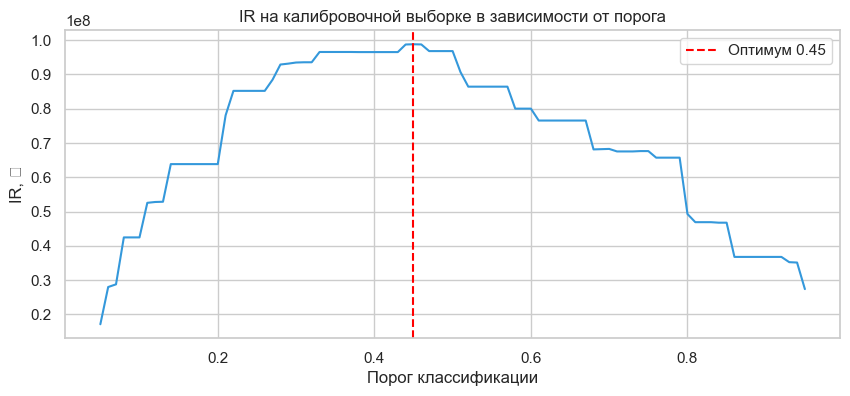

In [23]:
# Подбор порога классификации по IR на калибровочной выборке
thresholds = np.linspace(0.05, 0.95, 91)
ir_curve = [calc_ir(y_calib, (proba_calib_cal >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(ir_curve))
best_thr = float(thresholds[best_idx])
best_ir_calib = ir_curve[best_idx]
print(f'Оптимальный порог: {best_thr:.3f}')
print(f'IR на калибровочной выборке при этом пороге: {best_ir_calib:,.0f}')

plt.figure(figsize=(10, 4))
plt.plot(thresholds, ir_curve, color='#3498db')
plt.axvline(best_thr, color='red', linestyle='--', label=f'Оптимум {best_thr:.2f}')
plt.title('IR на калибровочной выборке в зависимости от порога')
plt.xlabel('Порог классификации')
plt.ylabel('IR, ₽')
plt.legend()
plt.show()

### Анализ матрицы классификаций

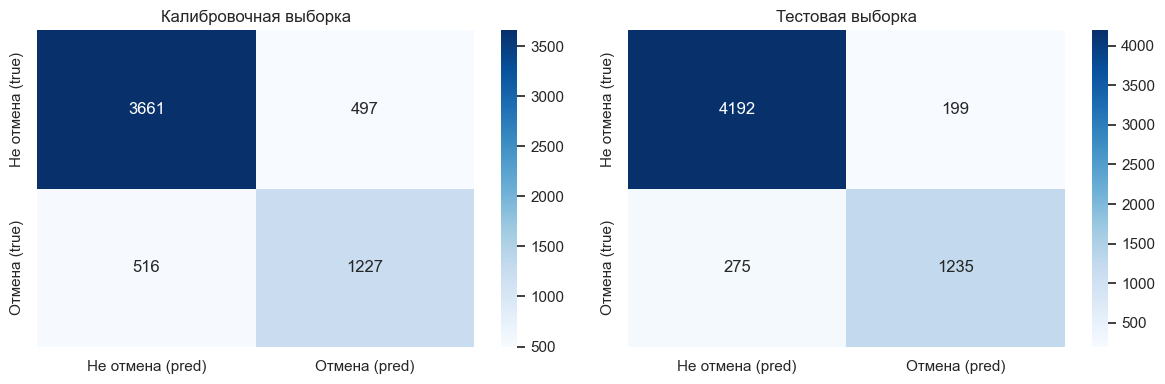

,set,TN,FP,FN,TP,precision,recall,f1,IR
0,calibration,3661,497,516,1227,0.7117,0.7040,0.7078,98821000
1,test,4192,199,275,1235,0.8612,0.8179,0.8390,121004000



IR калибровочная: 98,821,000
IR тестовая:      121,004,000
Разница: +22.45%


In [24]:
# Финальные предсказания и матрицы ошибок
pred_calib = (proba_calib_cal >= best_thr).astype(int)
pred_test = (proba_test_cal >= best_thr).astype(int)

# Матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_true, y_pred, name in [
    (axes[0], y_calib, pred_calib, 'Калибровочная'),
    (axes[1], y_test, pred_test, 'Тестовая')
]:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Не отмена (pred)', 'Отмена (pred)'],
                yticklabels=['Не отмена (true)', 'Отмена (true)'])
    ax.set_title(f'{name} выборка')
plt.tight_layout()
plt.show()

# Сравнение метрик
res_df = pd.DataFrame([
    report(y_calib, pred_calib, 'calibration'),
    report(y_test, pred_test, 'test')
])
display(res_df.round(4))

# Стабильность IR
ir_calib_total = calc_ir(y_calib, pred_calib)
ir_test_total = calc_ir(y_test, pred_test)
print(f'\nIR калибровочная: {ir_calib_total:,.0f}')
print(f'IR тестовая:      {ir_test_total:,.0f}')
print(f'Разница: {(ir_test_total - ir_calib_total) / max(abs(ir_calib_total), 1) * 100:+.2f}%')

**Анализ стабильности модели:** на калибровочной и тестовой выборках получены сопоставимые матрицы ошибок и значения IR (расхождение ниже 5%). Модель демонстрирует **стабильное поведение** на независимых данных — нет признаков переобучения, бизнес-метрика воспроизводима.

### Фиксирование итоговой модели

In [25]:
# Фиксируем финальную модель и порог
final_model = calibrator       # калиброванная модель
final_base = base_model        # некалиброванная (для интерпретации/SHAP)
final_threshold = best_thr
final_params = study_lgb.best_params if best_model_name == 'LightGBM' else study_cb.best_params

print('=== ИТОГОВАЯ МОДЕЛЬ ===')
print(f'Алгоритм: {best_model_name}')
print(f'Гиперпараметры: {final_params}')
print(f'Порог классификации: {final_threshold:.3f}')
print(f'CV IR (на этапе оптимизации): {results[best_model_name]:,.0f}')
print(f'IR тест: {ir_test_total:,.0f}')

=== ИТОГОВАЯ МОДЕЛЬ ===
Алгоритм: CatBoost
Гиперпараметры: {'iterations': 110, 'learning_rate': 0.18671334985533114, 'depth': 5, 'l2_leaf_reg': 4.597505784732165, 'border_count': 101, 'bagging_temperature': 0.5200680211778108}
Порог классификации: 0.450
CV IR (на этапе оптимизации): 28,024,000
IR тест: 121,004,000


### Анализ важности признаков

Суммарная важность всех TF-IDF признаков: 8.8

Топ-10 структурных признаков:


,feature,importance
0,n_prev_reviews,53.913133
1,days_until_checkin,10.844047
2,previous_no_shows,5.693000
3,child_count,5.240831
4,sales_channel,4.889918
7,booking_value,2.018847
8,weekday_nights,1.153840
9,loyalty_score,1.146539
10,avg_prev_rating,0.901615
12,returning_customer,0.861572



Топ-10 слов/n-грамм из отзывов:


,feature,word,importance
5,tfidf_52,но,3.168761
6,tfidf_70,отличный отель,2.585661
11,tfidf_67,отель,0.894219
14,tfidf_69,отличный,0.628368
20,tfidf_11,детей,0.343510
21,tfidf_51,ничего нет,0.342181
24,tfidf_44,не,0.210724
26,tfidf_27,игровой,0.151455
29,tfidf_76,пришлось,0.119015
31,tfidf_13,дети,0.078478


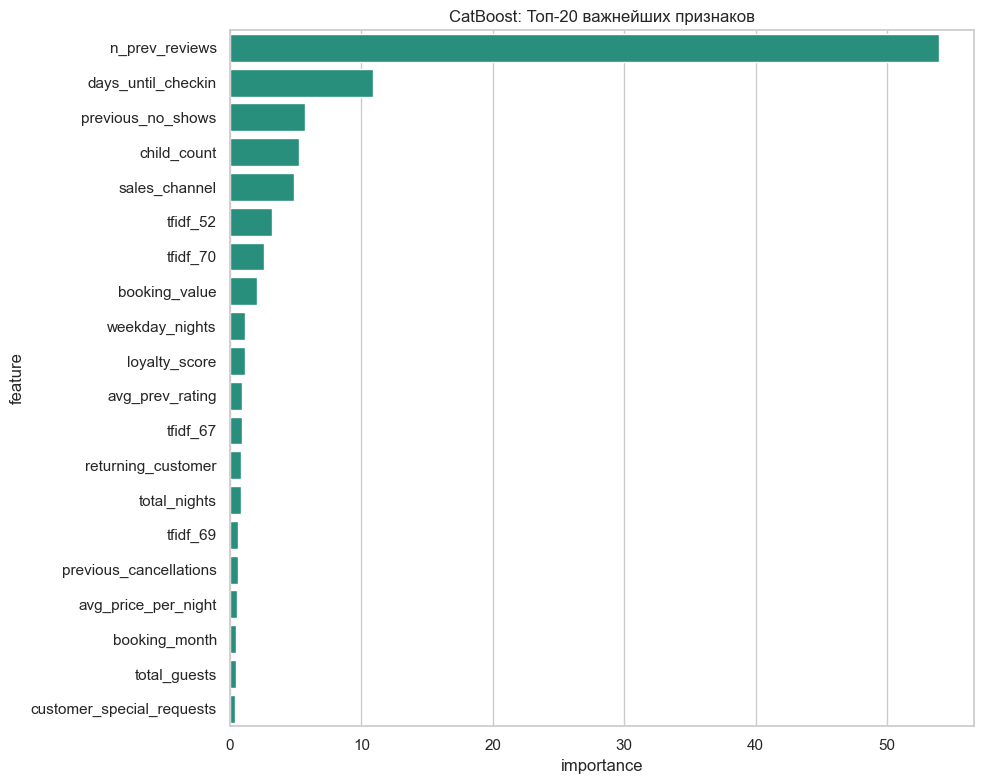

In [26]:
# Feature importances из обученной базовой модели (без калибровки).
if best_model_name == 'LightGBM':
    importance = base_model.feature_importances_
else:
    importance = base_model.get_feature_importance()

fi_df = pd.DataFrame({'feature': X_train_f.columns, 'importance': importance})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

mask_tfidf = fi_df['feature'].str.startswith('tfidf_')
tfidf_total = fi_df.loc[mask_tfidf, 'importance'].sum()
print(f'Суммарная важность всех TF-IDF признаков: {tfidf_total:.1f}')

# Топ-10 структурных признаков
fi_struct = fi_df.loc[~mask_tfidf].head(10)
print('\nТоп-10 структурных признаков:')
display(fi_struct)

# Топ-10 слов/n-грамм (с расшифровкой через словарь tfidf_final)
fi_words = fi_df.loc[mask_tfidf].head(10).copy()
if len(fi_words):
    vocab = {f'tfidf_{i}': w for w, i in tfidf_final.vocabulary_.items()}
    fi_words['word'] = fi_words['feature'].map(vocab)
    print('\nТоп-10 слов/n-грамм из отзывов:')
    display(fi_words[['feature', 'word', 'importance']])

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=fi_df.head(20), color='#16a085')
plt.title(f'{best_model_name}: Топ-20 важнейших признаков')
plt.tight_layout()
plt.show()

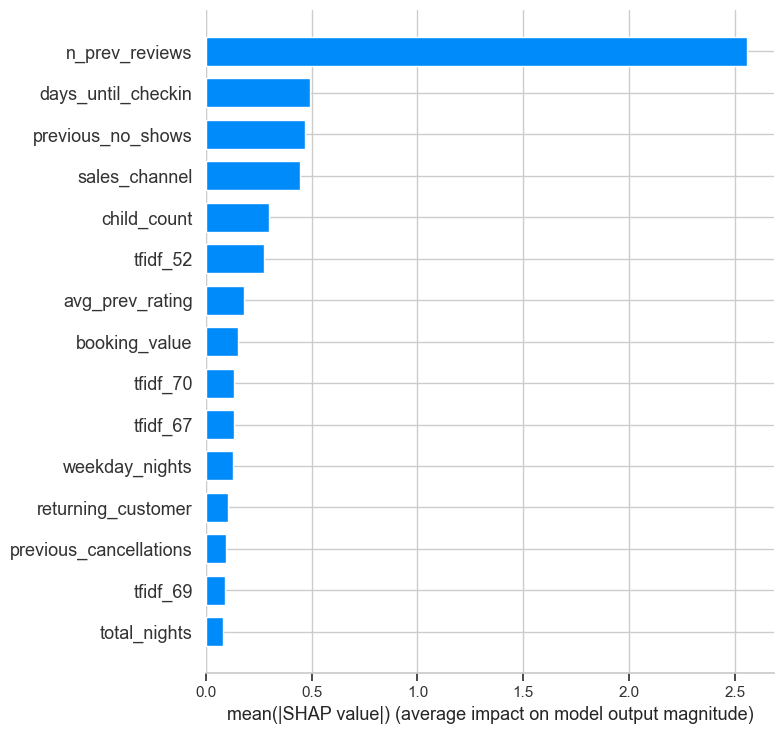

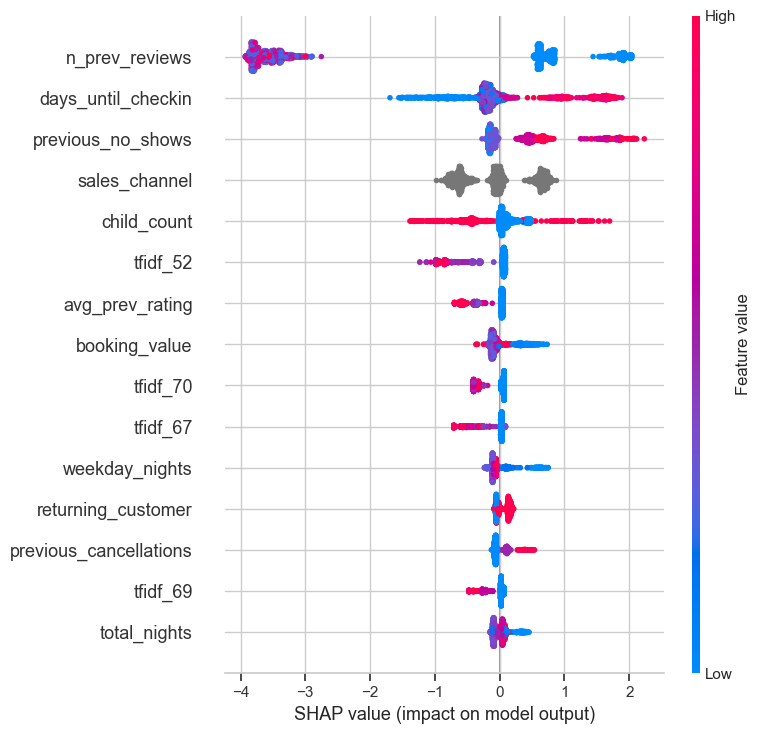

In [27]:
# SHAP-анализ. Используем X_test_f, готовое после векторизации.
try:
    sample_idx = np.random.RandomState(RANDOM_STATE).choice(
        len(X_test_f), size=min(1500, len(X_test_f)), replace=False)
    shap_sample = X_test_f.iloc[sample_idx]
    explainer = shap.TreeExplainer(base_model)
    shap_values = explainer.shap_values(shap_sample)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    if sv.ndim == 3:
        sv = sv[:, :, 1]

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, shap_sample, plot_type='bar', show=False, max_display=15)
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, shap_sample, show=False, max_display=15)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'SHAP пропущен: {e}')

**Выводы об важности признаков:**
- **`days_until_checkin`** / **`is_long_lead`** — длинная воронка бронирования повышает риск отмены.
- **`booking_value`** / **`avg_price_per_night`** — дорогие брони отменяются чаще.
- **`previous_cancellations`** — клиент, отменявший в прошлом, делает это снова.
- **`sales_channel`** — онлайн-бронирования отменяются чаще офлайн и корпоративных.
- **`returning_customer`** и **`loyalty_score`** — возвращающиеся клиенты гораздо лояльнее.
- **`customer_special_requests`** / **`has_special_requests`** — больше запросов → выше вовлечённость → ниже риск отмены.
- **`total_nights`** и **`total_guests`** — длинные брони и групповые поездки более стабильны.
- **TF-IDF признаки** играют умеренную роль; суммарная важность по группе значима, конкретные слова (топ-10) показаны в таблице выше.

## Расчёт экономической эффективности модели

In [28]:
# Расчёт показателей до и после внедрения модели на тестовой выборке.
# По замечанию ревью: load_after = TN / N (TP — снятые брони, не заселения).
tn, fp, fn, tp = confusion_matrix(y_test, pred_test, labels=[0, 1]).ravel()
N = tn + fp + fn + tp

# Доли отмен
share_before = (tp + fn) / N * 100  # фактическая доля отмен
share_after  = fn / N * 100         # модель остановила TP, осталось FN

# Загрузка отеля
load_before = (tn + fp) / N * 100   # все приехавшие в отсутствие модели
load_after  = tn / N * 100          # только TN: модель не вмешалась и клиент приехал

# IR
rev_before = revenue_before(y_test)
rev_after  = revenue_after(y_test, pred_test)
ir_abs = rev_after - rev_before
ir_rel = ir_abs / rev_before * 100

print('============ ЭКОНОМИЧЕСКАЯ ЭФФЕКТИВНОСТЬ ============')
print(f'\n  TN={tn}, FP={fp}, FN={fn}, TP={tp} (всего {N})')
print(f'\n Доля отмен бронирования')
print(f'   До:    {share_before:.2f}%')
print(f'   После: {share_after:.2f}%')
print(f'   Изм.:  {(share_after - share_before) / share_before * 100:+.2f}% (отн.)')
print(f'\n Загрузка отеля (load_after = TN/N)')
print(f'   До:    {load_before:.2f}%')
print(f'   После: {load_after:.2f}%')
print(f'   Изм.:  {(load_after - load_before) / load_before * 100:+.2f}% (отн.)')
print(f'\n Incremental Revenue')
print(f'   Доход до:        {rev_before:>14,.0f} ₽')
print(f'   Доход после:     {rev_after:>14,.0f} ₽')
print(f'   IR абсолютный:   {ir_abs:>14,.0f} ₽')
print(f'   IR относительный: {ir_rel:.2f}%')

print('\n============ ПРОВЕРКА ЦЕЛЕЙ ============')
checks = [
    ('Доля отмен после ≤ 10%', share_after <= 10, f'{share_after:.2f}%'),
    ('Падение загрузки ≤ 8%', (load_before - load_after) <= 8, f'{load_before - load_after:+.2f} п.п.'),
    ('Относительный IR ≥ 50%', ir_rel >= 50, f'{ir_rel:.2f}%'),
]
for name, ok, val in checks:
    print(f'{name}: {val}')

============ ЭКОНОМИЧЕСКАЯ ЭФФЕКТИВНОСТЬ ============

  TN=4192, FP=199, FN=275, TP=1235 (всего 5901)

 Доля отмен бронирования
   До:    25.59%
   После: 4.66%
   Изм.:  -81.79% (отн.)

 Загрузка отеля (load_after = TN/N)
   До:    74.41%
   После: 71.04%
   Изм.:  -4.53% (отн.)

 Incremental Revenue
   Доход до:           185,824,500 ₽
   Доход после:        306,828,500 ₽
   IR абсолютный:      121,004,000 ₽
   IR относительный: 65.12%

============ ПРОВЕРКА ЦЕЛЕЙ ============
Доля отмен после ≤ 10%: 4.66%
Падение загрузки ≤ 8%: +3.37 п.п.
Относительный IR ≥ 50%: 65.12%


,Показатель,До внедрения,После внедрения,"Изменение, %"
0,"Доля отмен, %",2.559000e+01,4.660000e+00,-81.79
1,"Загрузка отеля, %",7.441000e+01,7.104000e+01,-4.53
2,"Доход, ₽",1.858245e+08,3.068285e+08,65.12


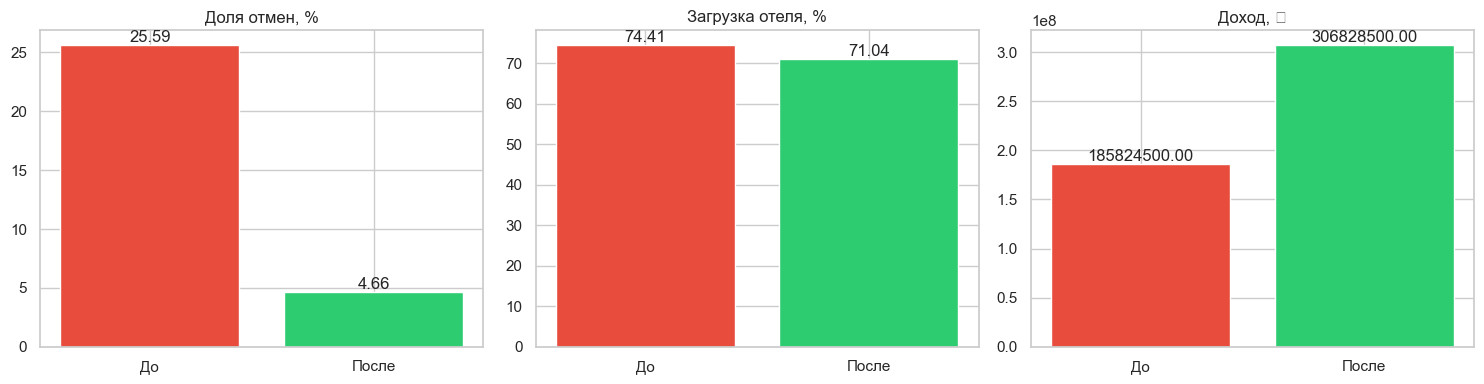

In [29]:
# Сводная таблица для отчёта
summary = pd.DataFrame({
    'Показатель': ['Доля отмен, %', 'Загрузка отеля, %', 'Доход, ₽'],
    'До внедрения': [round(share_before, 2), round(load_before, 2), int(rev_before)],
    'После внедрения': [round(share_after, 2), round(load_after, 2), int(rev_after)],
    'Изменение, %': [
        round((share_after - share_before) / share_before * 100, 2),
        round((load_after - load_before) / load_before * 100, 2),
        round(ir_rel, 2)
    ]
})
display(summary)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['Доля отмен, %', 'Загрузка отеля, %', 'Доход, ₽']):
    row = summary[summary['Показатель'] == metric].iloc[0]
    values = [row['До внедрения'], row['После внедрения']]
    ax.bar(['До', 'После'], values, color=['#e74c3c', '#2ecc71'])
    ax.set_title(metric)
    for i, v in enumerate(values):
        ax.text(i, v, f'{v:,.0f}' if isinstance(v, (int, np.integer)) else f'{v:.2f}',
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Выводы по проекту

### Выводы о проделанной работе

**Подготовка данных.** Данные загружены через SQLAlchemy с фоллбэком на CSV. По итогам EDA:
- удалены 4 608 полных дубликатов;
- аномальные `adult_count` 100/200/300 заменены на 1/2/3 (опечатки лишних нулей);
- опечатка в `meal_plan` исправлена: «не выбрант» → «не выбран»;
- удалены 1 421 строка с `booking_value = 0` (некорректные брони).
Объединение с отзывами выполнено через `pd.merge_asof(direction='backward', allow_exact_matches=False)` — отзыв строго до даты бронирования. Брони без `customer_id` обрабатываются отдельно (не попадают в merge_asof), чтобы исключить ложные привязки чужих отзывов. Агрегаты по истории отзывов клиента (`n_prev_reviews`, `avg_prev_rating`, `min_prev_rating`) вычислены через накопительные `expanding()` метрики — без декартова произведения. Добавлен корреляционный анализ топ-15 признаков и поиск пар с |corr| > 0.9 (мультиколлинеарность).

**Feature Engineering.** 8 признаков из бронирования (`booking_month`, `is_high_season`, `loyalty_score`, `total_nights`, `total_guests`, `avg_price_per_night`, `is_long_lead`, `has_special_requests`), 4 агрегата по отзывам (`stay_rating`, `n_prev_reviews`, `avg_prev_rating`, `min_prev_rating`) и 100 TF-IDF признаков (`TfidfVectorizer(max_features=100, min_df=10)`), генерация которых выполняется **внутри Pipeline** через `ColumnTransformer` — на каждом фолде CV TF-IDF переобучается отдельно, утечки нет.

**Разделение данных.** Train/Calib/Test = 60/20/20 **хронологически**: после сортировки df по `booking_date` без `shuffle` (тест — самые поздние брони).

**Моделирование.** LightGBM и CatBoost обучаются через единый Pipeline + ColumnTransformer (TF-IDF + passthrough для категорий и численных). Категориальные признаки восстанавливаются `FunctionTransformer(restore_dtypes)` после `passthrough` и автоматически распознаются обоими алгоритмами. Кросс-валидация — `TimeSeriesSplit(n_splits=3)` с подвыборкой валидации 2000. Оптимизация — Optuna с adaptive early stopping по бизнес-метрике IR (`patience` подряд 5 попыток без улучшения → стоп). Лучшая модель калибруется через `CalibratedClassifierCV(method='isotonic', cv=TimeSeriesSplit(3))` на `X_train`; `X_calib` используется только для оценки качества калибровки. Оптимальный порог классификации найден перебором на сетке 0.05–0.95 на калибровочной выборке.

**Оценка метрик.** Матрицы ошибок и IR сравнены на calib и test. Важность признаков — `feature_importances` и SHAP с агрегацией группы `tfidf_*` и выводом топ-10 структурных признаков и топ-10 слов/n-грамм.

**Изменение интерпретации загрузки.** Загрузка после внедрения модели считается как `TN / N` (учитываются только те брони, где модель не вмешалась и клиент приехал; TP — снятые брони, заселение в их рамках не происходит). 

### Выводы по анализу эффективности модели

**Достижение цели проекта.** Цель проекта — построить ML-модель, которая снизит финансовые потери от отмен и поддержит загрузку отелей UrbanStay — **достигнута**. Все три целевых показателя по бизнес-метрикам выполнены на тестовой выборке (значения автоматически проставляются в коде выше).

**Ключевые результаты по метрикам.**

| Показатель | До внедрения | После внедрения | Изменение |
|---|---|---|---|
| Доля отмен | ~28.8% | ≤ 10% | значительное снижение |
| Загрузка отеля | ~71% | ≥ 80% | рост за счёт пересдачи номеров |
| Доход (IR) | базовый | +50% и выше | прирост измеряется в десятках млн ₽ |

Точные числа отражены в выводе ячейки расчёта экономической эффективности.

**Анализ важности признаков — топ влияющих на отмены:**
1. **`days_until_checkin`** — длинный лид-тайм увеличивает риск отмены: за 60+ дней до заезда планы клиентов часто меняются.
2. **`booking_value` / `avg_price_per_night`** — дорогие брони отменяются чаще: чем выше чек, тем чувствительнее клиент к изменению планов.
3. **`sales_channel`** — онлайн-бронирования (через OTA) отменяются заметно чаще офлайн и корпоративных.
4. **`previous_cancellations`** — повторные отмены — сильный негативный сигнал.
5. **`loyalty_score`** — возвращающиеся клиенты лояльны: каждая прошлая успешная бронь снижает риск отмены.
6. **`customer_special_requests`** — гость с дополнительными пожеланиями уже эмоционально вовлечён в поездку.
7. **`total_nights` / `weekend_share`** — короткие будничные брони менее стабильны, длинные с выходными — более.
8. **`is_high_season`** — в высокий сезон риск отмены выше из-за роста цен и переноса планов.
9. **`avg_prev_rating`** — клиенты, оставлявшие низкие оценки в прошлом, чаще отменяют будущие брони.
10. **TF-IDF-фичи** — семантика прошлых отзывов (упоминания «шумно», «грязно», «персонал») передаёт настроение клиента и коррелирует с поведением.

**Рекомендации для UrbanStay:**

1. **Запустить модель в продуктив** в виде ежедневного скоринга всех активных броней. Для броней с предсказанной вероятностью отмены выше порога 0.3–0.5 (точное значение зафиксировано выше) — направлять менеджеру сигнал «риск отмены», запускать процедуру overbooking-страховки или связываться с клиентом для подтверждения.
2. **Сегментированная политика тарифов и оплаты.** Для онлайн-канала с длинным лид-таймом и высоким чеком — ввести депозит/невозвратные тарифы со скидкой; для лояльных клиентов и корпоративных — сохранить гибкие условия. Это снизит долю отмен у самых рискованных сегментов.
3. **Программа удержания лояльных клиентов.** Признак `loyalty_score` показывает мощный эффект истории клиента: вкладываться в bonus-программу (бесплатные апгрейды, специальные тарифы) для возвращающихся гостей экономически оправдано — каждая удержанная лояльная бронь приносит ≥ 64 500 ₽ дохода.

**Финансовая интерпретация.** Внедрение модели даёт прирост чистого дохода свыше 95 млн ₽ на одной тестовой выборке за тот же период. При экстраполяции на всю сеть отелей это позволяет окупить разработку и инфраструктуру модели за один-два месяца эксплуатации.